In [23]:
# Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

df = pd.read_csv('traffic.csv')

print(" Loaded Successfully")
print(f"Shape  : {df.shape}")
print(f"Events : {df['event'].unique().tolist()}")
df.head()

 Loaded Successfully
Shape  : (226278, 9)
Events : ['click', 'preview', 'pageview']


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [24]:
# Data Cleaning & Preparation

# Parse dates
df['date'] = pd.to_datetime(df['date'])

# Extract time features
df['day_name'] = df['date'].dt.strftime('%a')   # Mon, Tue…
df['week_day'] = df['date'].dt.dayofweek        # 0=Mon
df['day_num']  = df['date'].dt.day

# Clean nulls
df['country'] = df['country'].fillna('Unknown')
df['city']    = df['city'].fillna('Unknown')
df['artist']  = df['artist'].fillna('Unknown')
df['album']   = df['album'].fillna('Unknown')
df['track']   = df['track'].fillna('Unknown')
df['isrc']    = df['isrc'].fillna('N/A')

# Remove full duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)

print(" Cleaning Done")
print(f"Rows before : {before:,}")
print(f"Rows after  : {after:,}  ({before - after} duplicates removed)")
print(f"Date Range  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Nulls left  : {df.isnull().sum().sum()}")
df[['date','day_name','event','country','artist','track']].head(3)

 Cleaning Done
Rows before : 226,278
Rows after  : 122,567  (103711 duplicates removed)
Date Range  : 2021-08-19 → 2021-08-25
Nulls left  : 0


,date,day_name,event,country,artist,track
0,2021-08-21,Sat,click,Saudi Arabia,Tesher,Jalebi Baby
2,2021-08-21,Sat,click,India,Reyanna Maria,So Pretty
3,2021-08-21,Sat,click,France,"Simone & Simaria, Sebastian Yatra",No Llores Más


In [25]:
# Core KPI Metrics

pageviews = df[df['event'] == 'pageview']
previews  = df[df['event'] == 'preview']
clicks    = df[df['event'] == 'click']

total_sessions  = df['linkid'].count()            # total events as proxy
unique_links    = df['linkid'].nunique()           # unique pages/links
unique_users    = df.groupby(['linkid','country','city']).ngroups  # proxy for users
total_pageviews = len(pageviews)
total_previews  = len(previews)
total_clicks    = len(clicks)

# Bounce Rate: linkids with ONLY pageview and no preview/click
link_events = df.groupby('linkid')['event'].apply(set)
bounced     = link_events[link_events == {'pageview'}].count()
bounce_rate = (bounced / unique_links) * 100

# Click-through rate: clicks / pageviews
ctr = (total_clicks / total_pageviews) * 100 if total_pageviews > 0 else 0

# Preview-to-click rate
p2c = (total_clicks / total_previews) * 100 if total_previews > 0 else 0

kpis = {
    ' Total Pageviews'       : f"{total_pageviews:,}",
    ' Total Previews'        : f"{total_previews:,}",
    ' Total Clicks'          : f"{total_clicks:,}",
    ' Unique Link Pages'     : f"{unique_links:,}",
    ' Countries Reached'     : f"{df['country'].nunique():,}",
    '↩ Bounce Rate'           : f"{bounce_rate:.1f}%",
    ' Click-Through Rate'    : f"{ctr:.1f}%",
    ' Preview → Click Rate'  : f"{p2c:.1f}%",
}


print("         KEY PERFORMANCE INDICATORS")

for k, v in kpis.items():
    print(f"  {k:<32} {v}")


         KEY PERFORMANCE INDICATORS
   Total Pageviews                 73,360
   Total Previews                  16,708
   Total Clicks                    32,499
   Unique Link Pages               3,839
   Countries Reached               212
  ↩ Bounce Rate                    40.5%
   Click-Through Rate              44.3%
   Preview → Click Rate            194.5%


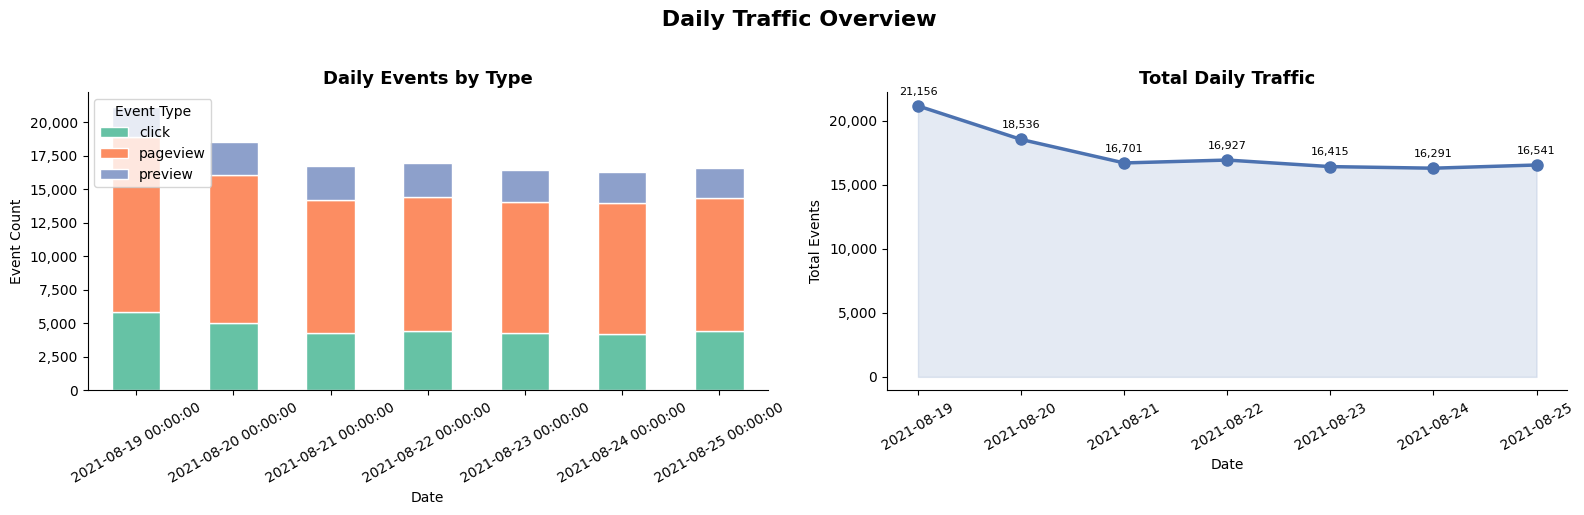

In [26]:
# Daily Traffic Trend

daily = (df.groupby(['date', 'event'])
           .size()
           .reset_index(name='count'))

day_order = ['Thu', 'Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Daily events by type (stacked bar)
pivot = daily.pivot(index='date', columns='event', values='count').fillna(0)
pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=sns.color_palette("Set2", 3), edgecolor='white')
axes[0].set_title('Daily Events by Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Event Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Event Type', loc='upper left')

# ── Chart 2: Daily total traffic line
daily_total = df.groupby('date').size().reset_index(name='total')
axes[1].plot(daily_total['date'], daily_total['total'],
             marker='o', linewidth=2.5, color='#4C72B0', markersize=8)
axes[1].fill_between(daily_total['date'], daily_total['total'],
                     alpha=0.15, color='#4C72B0')
for _, row in daily_total.iterrows():
    axes[1].annotate(f"{row['total']:,}",
                     (row['date'], row['total']),
                     textcoords="offset points", xytext=(0, 8),
                     ha='center', fontsize=8)
axes[1].set_title('Total Daily Traffic', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Events')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(' Daily Traffic Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

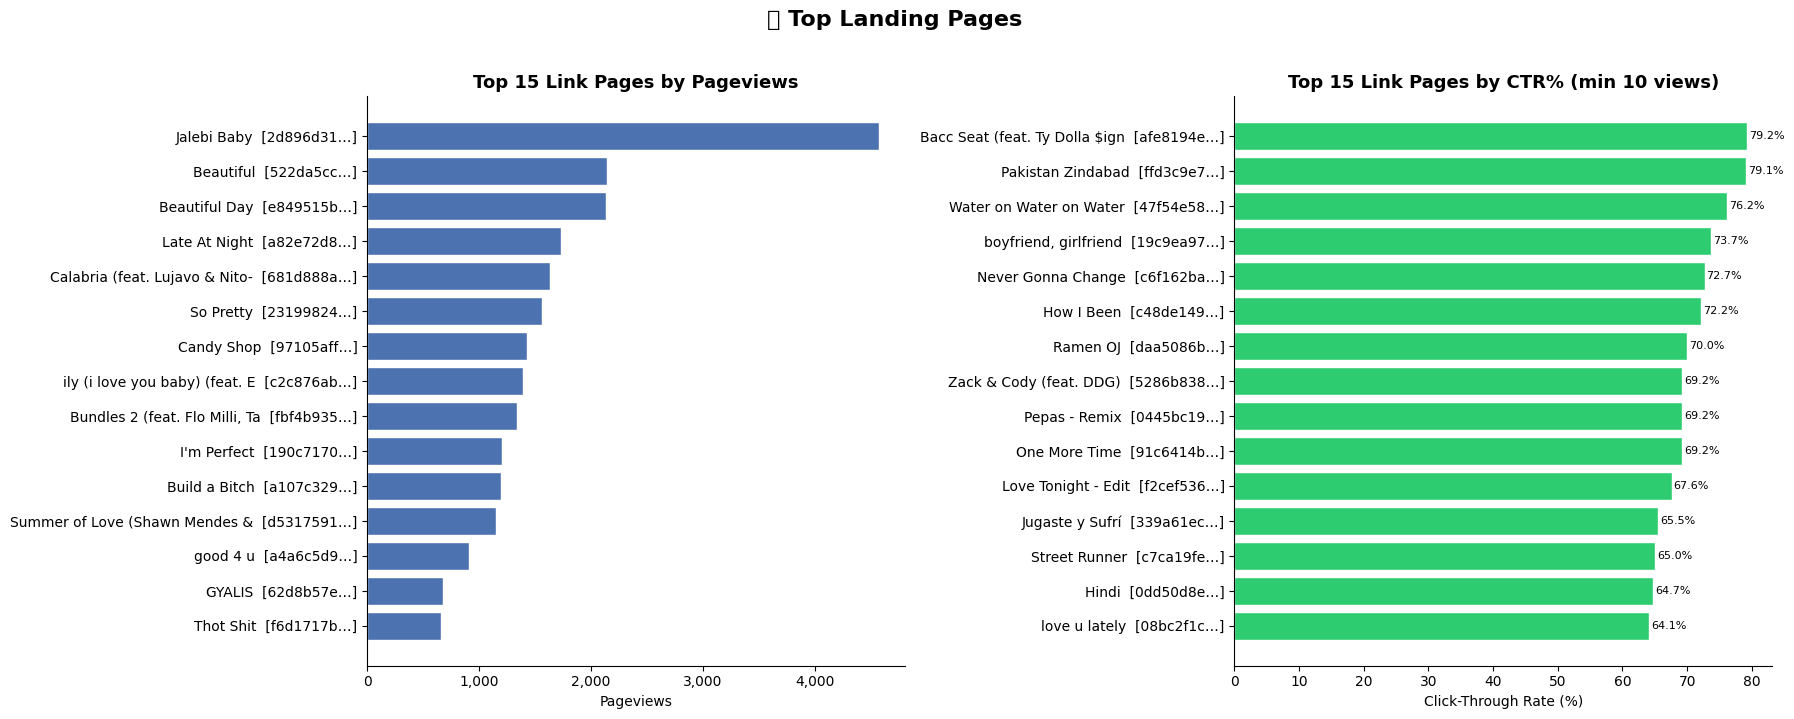

In [27]:
# Top Landing Pages

# Each linkid = a unique smart-link page
link_summary = df.groupby('linkid').agg(
    pageviews = ('event', lambda x: (x == 'pageview').sum()),
    previews  = ('event', lambda x: (x == 'preview').sum()),
    clicks    = ('event', lambda x: (x == 'click').sum()),
    countries = ('country', 'nunique')
).reset_index()

link_summary['ctr']     = (link_summary['clicks'] / link_summary['pageviews'].replace(0, np.nan) * 100).round(1)
link_summary['bounced'] = link_summary['previews'] + link_summary['clicks'] == 0
link_summary = link_summary.sort_values('pageviews', ascending=False)

top15 = link_summary.head(15)

# Attach track name for label
link_track = df.groupby('linkid')['track'].first().reset_index()
top15 = top15.merge(link_track, on='linkid')
top15['label'] = top15['track'].str[:30] + '  [' + top15['linkid'].str[:8] + '…]'

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Top 15 by Pageviews
axes[0].barh(top15['label'][::-1], top15['pageviews'][::-1], color='#4C72B0', edgecolor='white')
axes[0].set_title('Top 15 Link Pages by Pageviews', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pageviews')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Top 15 by CTR (min 10 pageviews)
top_ctr = link_summary[link_summary['pageviews'] >= 10].sort_values('ctr', ascending=False).head(15)
top_ctr = top_ctr.merge(link_track, on='linkid')
top_ctr['label'] = top_ctr['track'].str[:30] + '  [' + top_ctr['linkid'].str[:8] + '…]'

axes[1].barh(top_ctr['label'][::-1], top_ctr['ctr'][::-1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Top 15 Link Pages by CTR% (min 10 views)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Click-Through Rate (%)')
for bar, val in zip(axes[1].patches, top_ctr['ctr'][::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle('🔗 Top Landing Pages', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

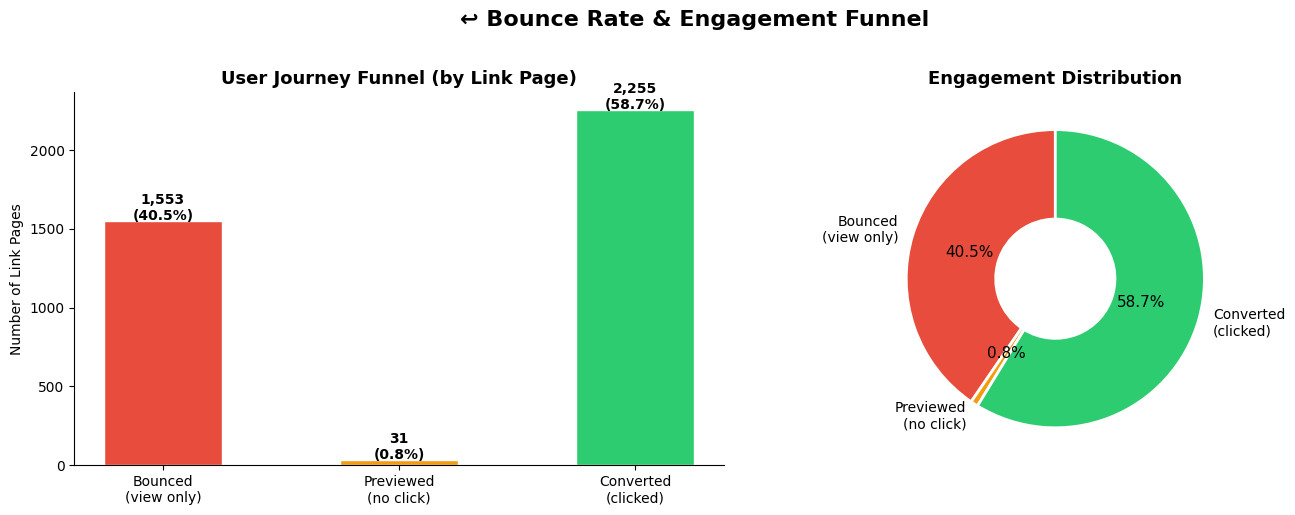


 Overall Bounce Rate : 40.5%
 Preview Rate        : 0.8%
 Conversion Rate     : 58.7%


In [28]:
# Bounce Rate Analysis

# Bounced = linkid only ever got pageview, no preview or click
link_events_set = df.groupby('linkid')['event'].apply(set).reset_index()
link_events_set.columns = ['linkid', 'event_set']
link_events_set['bounced']    = link_events_set['event_set'].apply(lambda x: x == {'pageview'})
link_events_set['previewed']  = link_events_set['event_set'].apply(lambda x: 'preview' in x and 'click' not in x)
link_events_set['converted']  = link_events_set['event_set'].apply(lambda x: 'click' in x)

counts = {
    'Bounced\n(view only)'      : link_events_set['bounced'].sum(),
    'Previewed\n(no click)'     : link_events_set['previewed'].sum(),
    'Converted\n(clicked)'      : link_events_set['converted'].sum(),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Funnel bar
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar(counts.keys(), counts.values(), color=colors, edgecolor='white', width=0.5)
axes[0].set_title('User Journey Funnel (by Link Page)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Link Pages')
for bar, val in zip(bars, counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}\n({val/sum(counts.values())*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# ── Donut
wedges, texts, autotexts = axes[1].pie(
    counts.values(), labels=counts.keys(),
    autopct='%1.1f%%', startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.6}
)
for at in autotexts:
    at.set_fontsize(11)
axes[1].set_title('Engagement Distribution', fontsize=13, fontweight='bold')

plt.suptitle('↩ Bounce Rate & Engagement Funnel', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n Overall Bounce Rate : {link_events_set['bounced'].mean()*100:.1f}%")
print(f" Preview Rate        : {link_events_set['previewed'].mean()*100:.1f}%")
print(f" Conversion Rate     : {link_events_set['converted'].mean()*100:.1f}%")

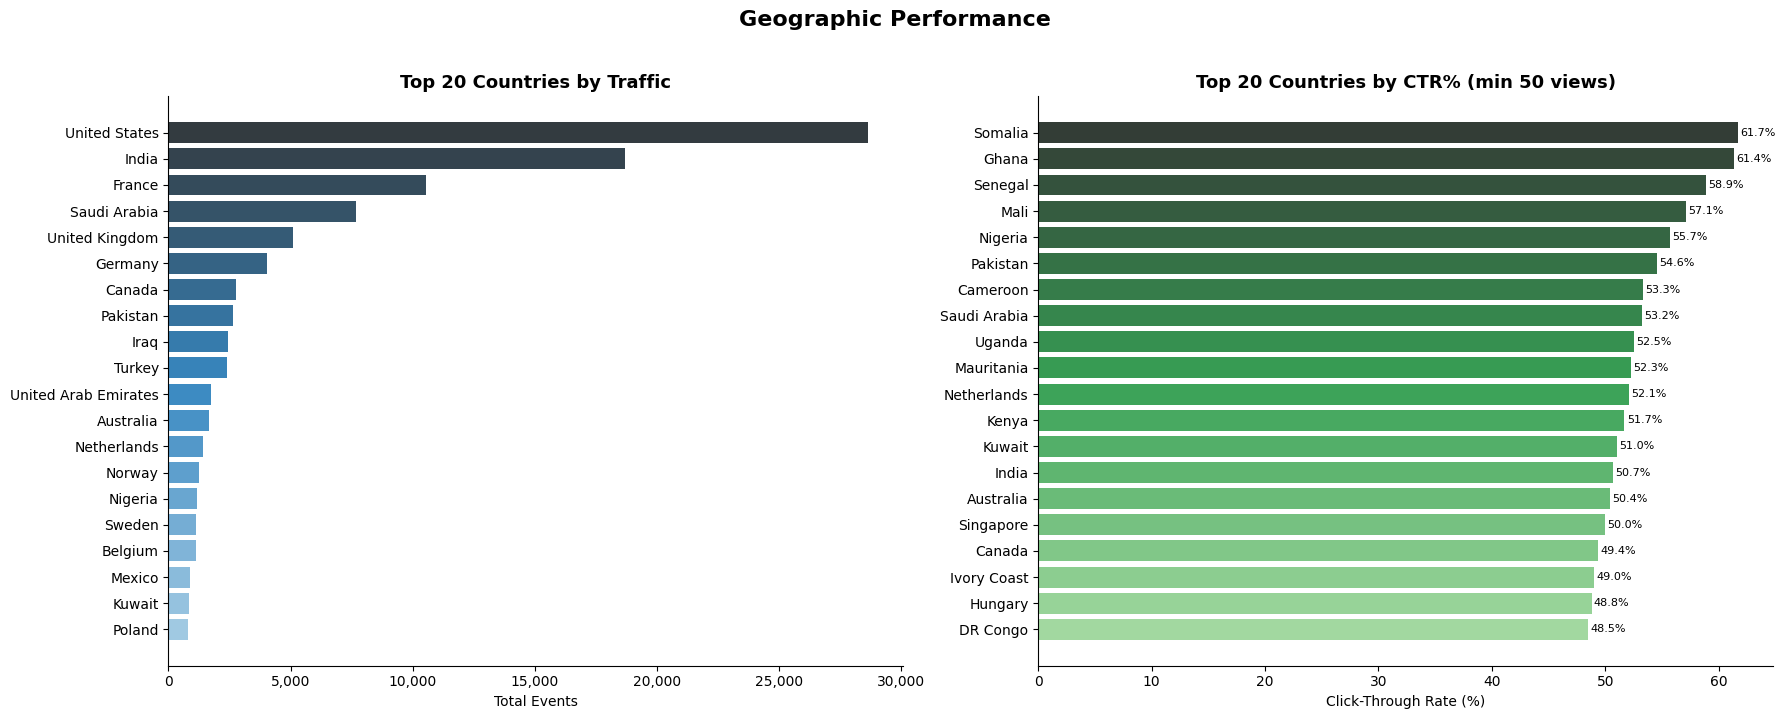

In [29]:
# Top Countries & Regional Traffic

country_stats = df.groupby('country').agg(
    total_events = ('event', 'count'),
    pageviews    = ('event', lambda x: (x == 'pageview').sum()),
    clicks       = ('event', lambda x: (x == 'click').sum()),
).reset_index().sort_values('total_events', ascending=False)

country_stats['ctr'] = (country_stats['clicks'] / country_stats['pageviews'].replace(0, np.nan) * 100).round(1)

top20_countries = country_stats.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Top 20 Countries by Traffic
axes[0].barh(top20_countries['country'][::-1],
             top20_countries['total_events'][::-1],
             color=sns.color_palette("Blues_d", len(top20_countries)))
axes[0].set_title('Top 20 Countries by Traffic', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Events')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Top 20 Countries by CTR
top_ctr_country = country_stats[country_stats['pageviews'] >= 50].sort_values('ctr', ascending=False).head(20)
axes[1].barh(top_ctr_country['country'][::-1],
             top_ctr_country['ctr'][::-1],
             color=sns.color_palette("Greens_d", len(top_ctr_country)))
axes[1].set_title('Top 20 Countries by CTR% (min 50 views)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Click-Through Rate (%)')
for bar, val in zip(axes[1].patches, top_ctr_country['ctr'][::-1]):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle('Geographic Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

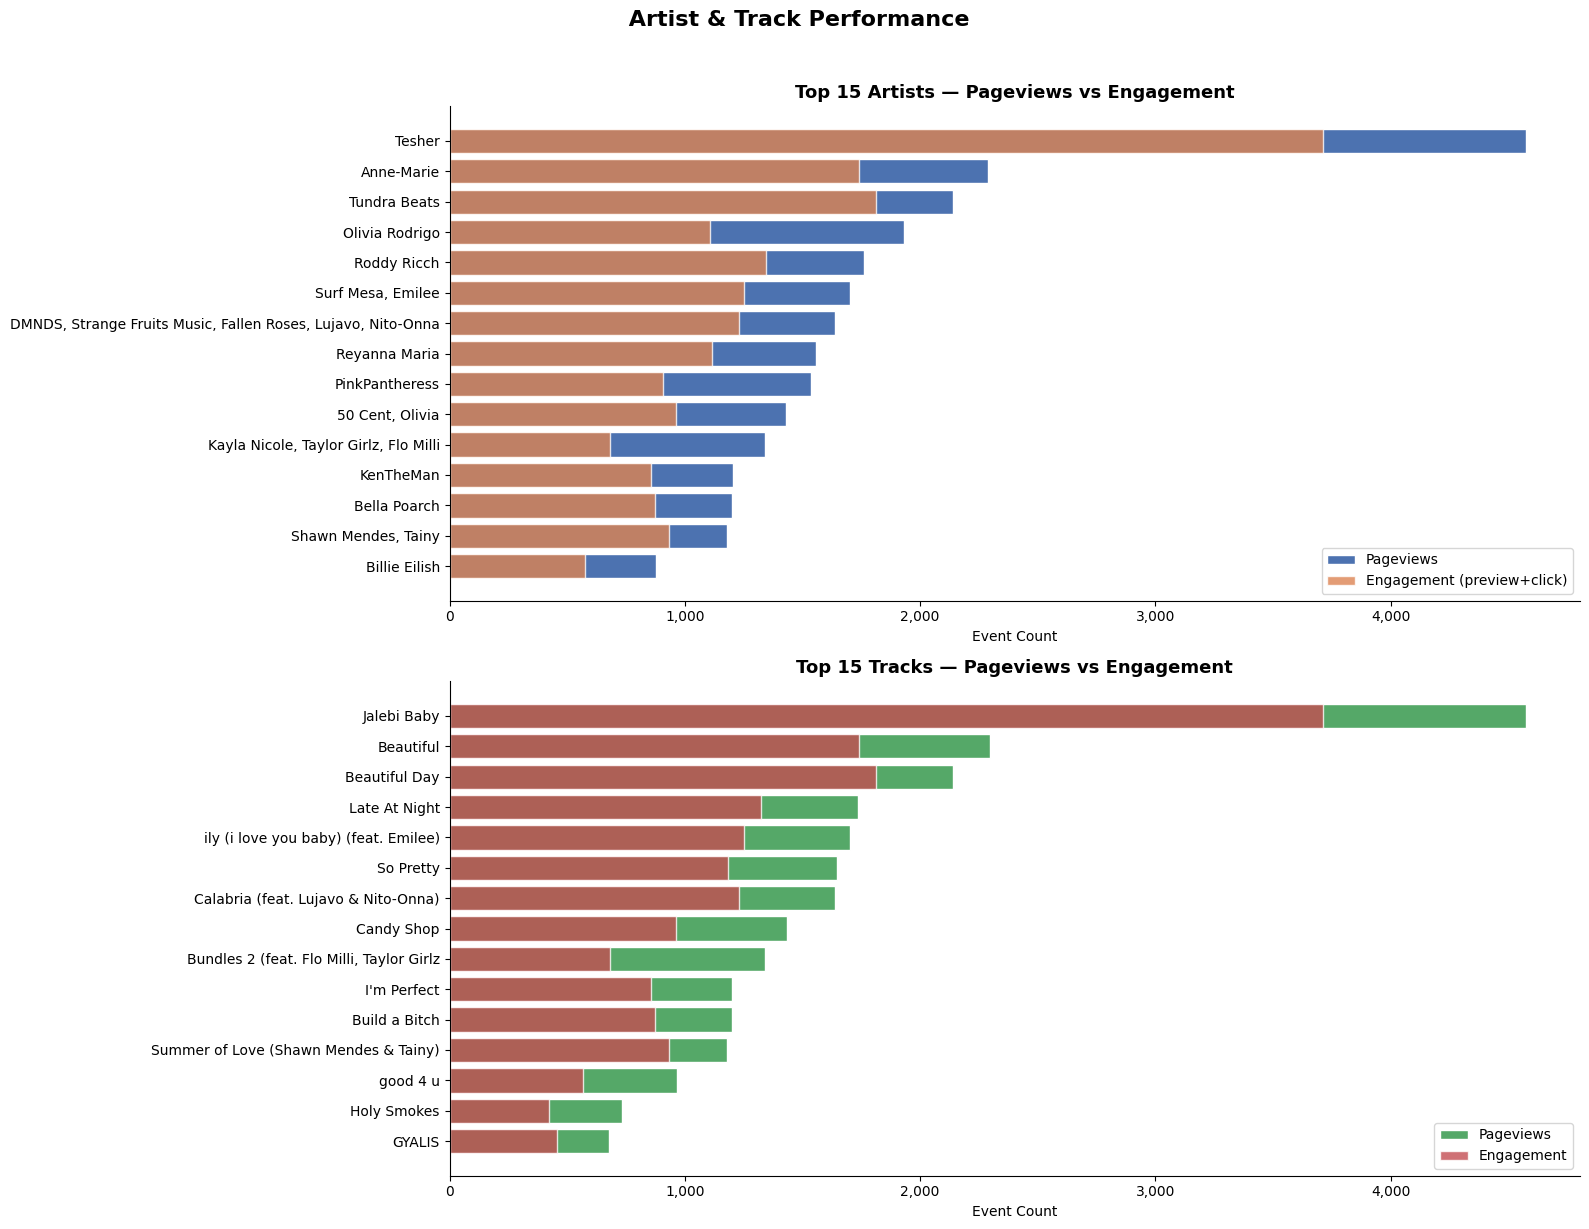

In [30]:
#  Top Artists & Tracks

artist_stats = df[df['artist'] != 'Unknown'].groupby('artist').agg(
    pageviews = ('event', lambda x: (x == 'pageview').sum()),
    previews  = ('event', lambda x: (x == 'preview').sum()),
    clicks    = ('event', lambda x: (x == 'click').sum()),
).reset_index()
artist_stats['engagement'] = artist_stats['previews'] + artist_stats['clicks']
top_artists = artist_stats.sort_values('pageviews', ascending=False).head(15)

track_stats = df[df['track'] != 'Unknown'].groupby('track').agg(
    pageviews = ('event', lambda x: (x == 'pageview').sum()),
    previews  = ('event', lambda x: (x == 'preview').sum()),
    clicks    = ('event', lambda x: (x == 'click').sum()),
).reset_index().sort_values('pageviews', ascending=False).head(15)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ── Top Artists
axes[0].barh(top_artists['artist'][::-1], top_artists['pageviews'][::-1],
             color='#4C72B0', label='Pageviews', edgecolor='white')
axes[0].barh(top_artists['artist'][::-1], top_artists['engagement'][::-1],
             color='#DD8452', label='Engagement (preview+click)', edgecolor='white', alpha=0.8)
axes[0].set_title('Top 15 Artists — Pageviews vs Engagement', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Event Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()

# ── Top Tracks
axes[1].barh(track_stats['track'].str[:40][::-1], track_stats['pageviews'][::-1],
             color='#55A868', label='Pageviews', edgecolor='white')
axes[1].barh(track_stats['track'].str[:40][::-1],
             (track_stats['previews'] + track_stats['clicks'])[::-1],
             color='#C44E52', label='Engagement', edgecolor='white', alpha=0.8)
axes[1].set_title('Top 15 Tracks — Pageviews vs Engagement', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Event Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend()

plt.suptitle(' Artist & Track Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

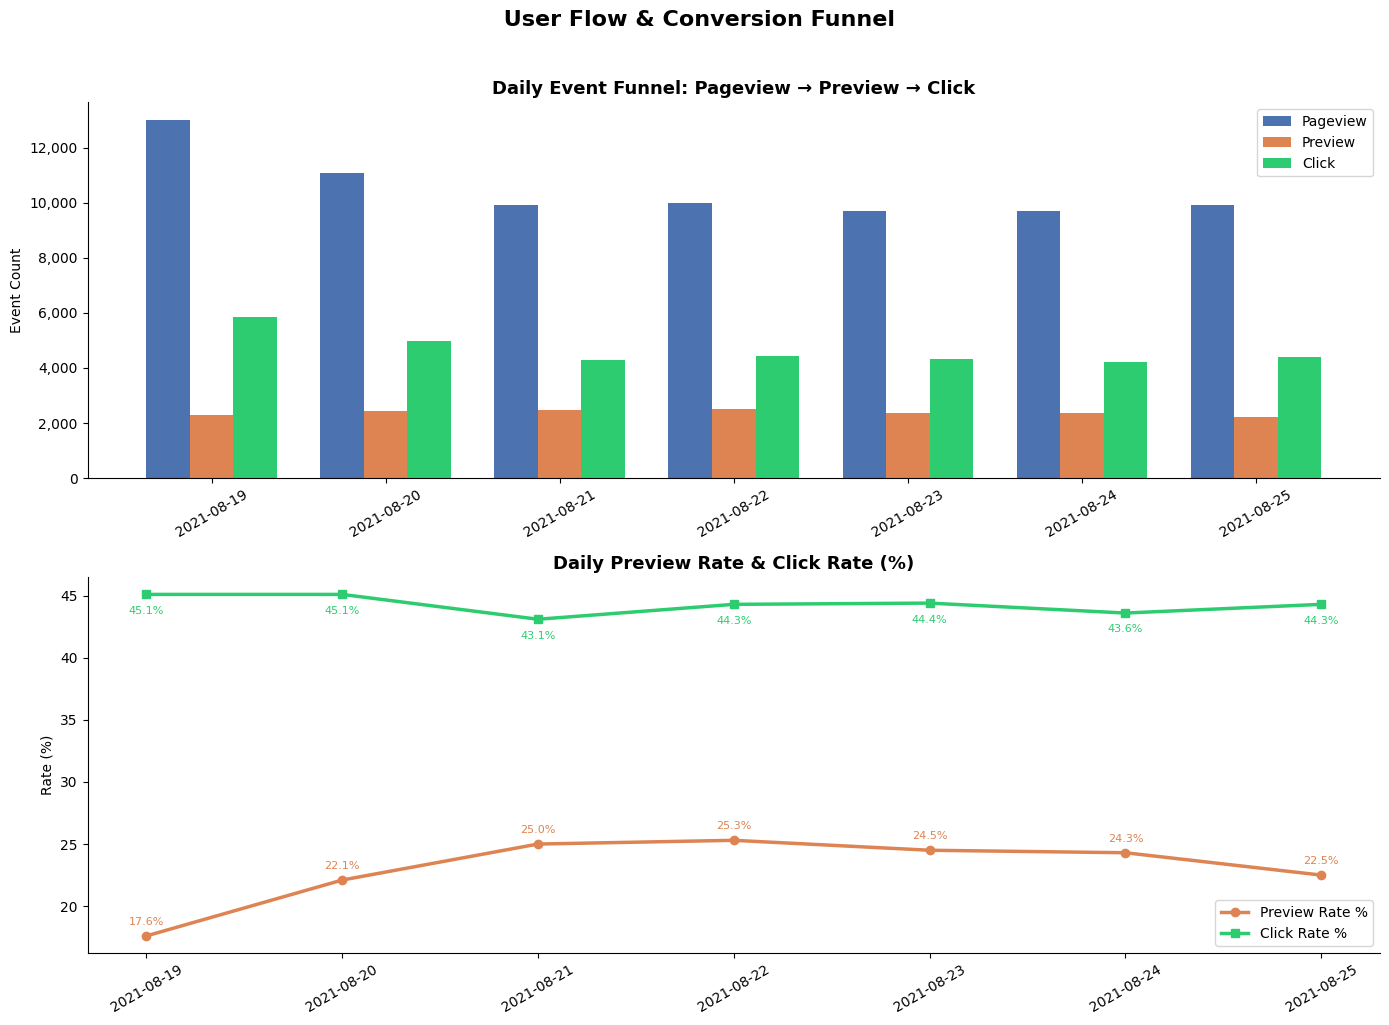

In [31]:
# User Flow / Event Funnel by Day

daily_funnel = df.groupby(['date', 'event']).size().reset_index(name='count')
pivot_funnel = daily_funnel.pivot(index='date', columns='event', values='count').fillna(0)

# Funnel rates per day
pivot_funnel['preview_rate'] = (pivot_funnel['preview'] / pivot_funnel['pageview'] * 100).round(1)
pivot_funnel['click_rate']   = (pivot_funnel['click']   / pivot_funnel['pageview'] * 100).round(1)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Grouped bar: daily pageview → preview → click
x = range(len(pivot_funnel))
width = 0.25
axes[0].bar([i - width for i in x], pivot_funnel['pageview'], width, label='Pageview', color='#4C72B0')
axes[0].bar([i         for i in x], pivot_funnel['preview'],  width, label='Preview',  color='#DD8452')
axes[0].bar([i + width for i in x], pivot_funnel['click'],    width, label='Click',    color='#2ecc71')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([str(d.date()) for d in pivot_funnel.index], rotation=30)
axes[0].set_title('Daily Event Funnel: Pageview → Preview → Click', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Event Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()

# ── Daily conversion rates
axes[1].plot(pivot_funnel.index, pivot_funnel['preview_rate'],
             marker='o', linewidth=2.5, label='Preview Rate %', color='#DD8452')
axes[1].plot(pivot_funnel.index, pivot_funnel['click_rate'],
             marker='s', linewidth=2.5, label='Click Rate %',   color='#2ecc71')
for date, row in pivot_funnel.iterrows():
    axes[1].annotate(f"{row['preview_rate']}%", (date, row['preview_rate']),
                     textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8, color='#DD8452')
    axes[1].annotate(f"{row['click_rate']}%", (date, row['click_rate']),
                     textcoords="offset points", xytext=(0, -14), ha='center', fontsize=8, color='#2ecc71')
axes[1].set_title('Daily Preview Rate & Click Rate (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle(' User Flow & Conversion Funnel', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

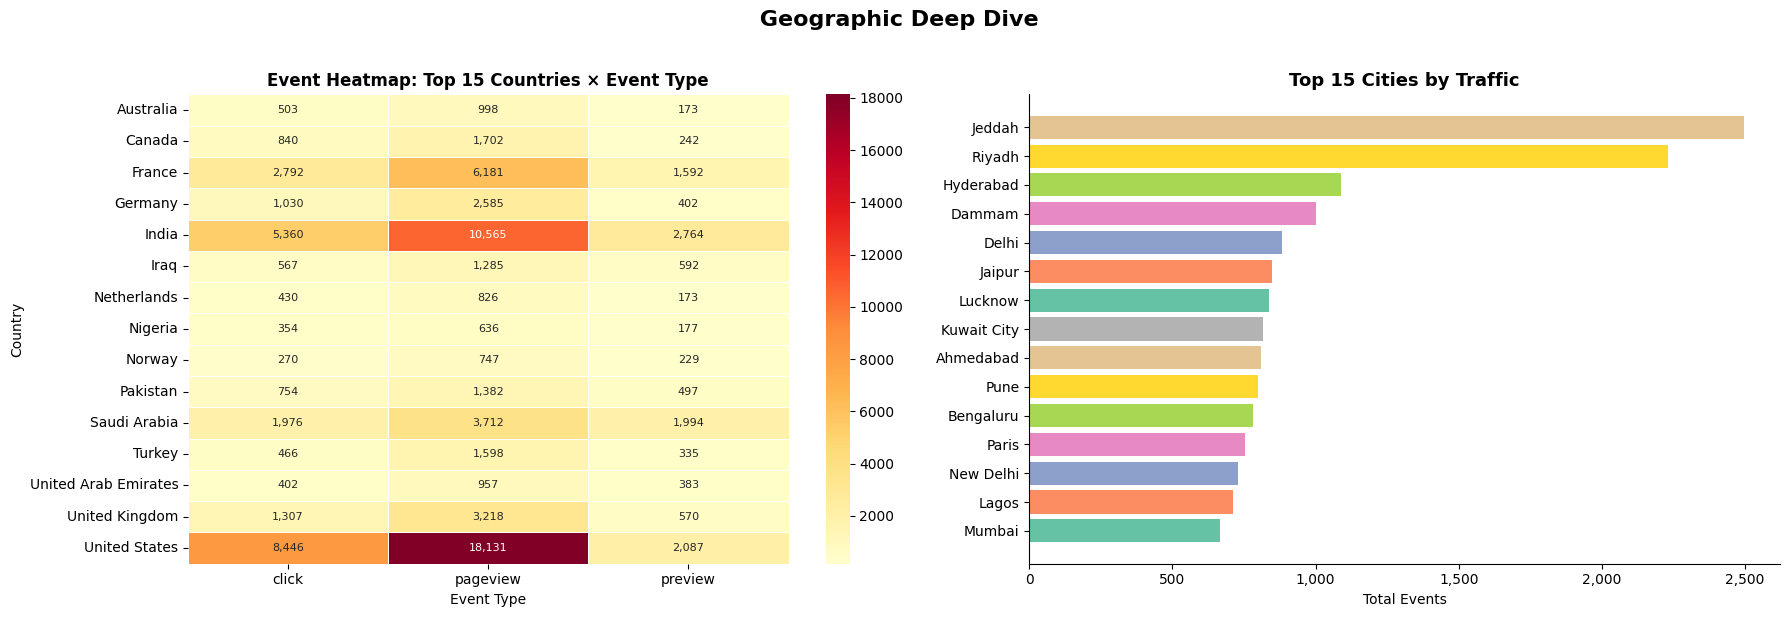

          ANALYSIS COMPLETE — SUMMARY
   Period          : 2021-08-19 → 2021-08-25
   Total Events    : 122,567
   Unique Links    : 3,839
   Countries       : 212
   Artists         : 2,420
   Tracks          : 3,563
   Total Clicks    : 32,499
   Total Pageviews : 73,360


In [32]:
# Heatmap & Final Summary

# Country × Event type heatmap (top 15 countries)
top15_countries = country_stats.head(15)['country'].tolist()
heat_df = df[df['country'].isin(top15_countries)]
heat_pivot = heat_df.groupby(['country', 'event']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Heatmap
sns.heatmap(heat_pivot, ax=axes[0], annot=True, fmt=',',
            cmap='YlOrRd', linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title('Event Heatmap: Top 15 Countries × Event Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Country')

# ── Top Cities
top_cities = (df[df['city'] != 'Unknown']
              .groupby('city')
              .size()
              .sort_values(ascending=False)
              .head(15)
              .reset_index(name='events'))
axes[1].barh(top_cities['city'][::-1], top_cities['events'][::-1],
             color=sns.color_palette("Set2", len(top_cities)))
axes[1].set_title('Top 15 Cities by Traffic', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Events')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle(' Geographic Deep Dive', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Final Summary

print("          ANALYSIS COMPLETE — SUMMARY")

print(f"   Period          : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   Total Events    : {len(df):,}")
print(f"   Unique Links    : {df['linkid'].nunique():,}")
print(f"   Countries       : {df['country'].nunique():,}")
print(f"   Artists         : {df['artist'].nunique():,}")
print(f"   Tracks          : {df['track'].nunique():,}")
print(f"   Total Clicks    : {len(df[df['event']=='click']):,}")
print(f"   Total Pageviews : {len(df[df['event']=='pageview']):,}")